In [1]:
import torch
from torch.utils.cpp_extension import load_inline

In [2]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 6.8 MB/s eta 0:00:00


In [3]:
Softmax_CUDA_Source = '''
#include <torch/extension.h>
#include <cuda.h>
#include <cuda_runtime.h>
#include <math.h>

#define BLOCK_DIM 1024

__global__ void FusedSoftmax_kernel(float* input, float* output, int layer_size) {
  __shared__ float input_s[BLOCK_DIM];
  __shared__ float s_max;
  __shared__ float s_sum;

  int batch_idx = blockIdx.x;
  int local_idx = threadIdx.x;
  int global_idx = batch_idx * layer_size + local_idx;

  float original_val = -INFINITY;
  if (local_idx < layer_size) {
    original_val = input[global_idx];
  }

  input_s[local_idx] = original_val;
  __syncthreads();

  for (unsigned int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
    if (local_idx < stride) {
      input_s[local_idx] = fmaxf(input_s[local_idx], input_s[local_idx + stride]);
    }
    __syncthreads();
  }

  if (local_idx == 0) {
    s_max = input_s[0];
  }

  __syncthreads();

  float exp_val = 0.0f;
  if (local_idx < layer_size) {
    exp_val = expf(original_val - s_max);
  }

  input_s[local_idx] = exp_val;

  __syncthreads();

  for (unsigned int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
    if (local_idx < stride) {
      input_s[local_idx] += input_s[local_idx + stride];
    }
    __syncthreads();
  }

  if (local_idx == 0) {
    s_sum = input_s[0];
  }

  __syncthreads();

  if (local_idx < layer_size) {
    output[global_idx] = exp_val / s_sum;
  }
}

torch::Tensor fused_softmax_forward(torch::Tensor input) {
  int batch_size = input.size(0);
  int layer_size = input.size(1);

  auto output = torch::empty_like(input);

  dim3 threadsPerBlock(BLOCK_DIM);
  dim3 numBlocks(batch_size);

  FusedSoftmax_kernel<<<numBlocks, threadsPerBlock>>>(input.data_ptr<float>(), output.data_ptr<float>(), layer_size);

  return output;
}
'''

In [4]:
Softmax_cpp_source = "torch::Tensor fused_softmax_forward(torch::Tensor input);"

In [5]:
my_module = load_inline(name="Softmax", cpp_sources=[Softmax_cpp_source], cuda_sources=[Softmax_CUDA_Source], functions=["fused_softmax_forward"], with_cuda=True, extra_cuda_cflags=["-O3"])

In [6]:
x = torch.randn(4, 800, device='cuda', dtype=torch.float32)

custom_output = my_module.fused_softmax_forward(x)

pytorch_output = torch.nn.functional.softmax(x, dim=-1)

is_correct = torch.allclose(custom_output, pytorch_output, atol=1e-5)

print(f"Custom Fused Softmax vs PyTorch Native Match: {is_correct}")
if is_correct:
    print("My double-reduction architecture is mathematically the same as PyTorch")

Custom Fused Softmax vs PyTorch Native Match: True
My double-reduction architecture is mathematically the same as PyTorch


# Benchmarking

In [15]:
import torch.nn.functional as F

batch_size = 64
layer_size = 1024
x = torch.randn(batch_size, layer_size, device='cuda', dtype=torch.float32)

print(f"Warming up GPU for tensor shape: [{batch_size}, {layer_size}]...")

for _ in range(10):
    _ = my_module.fused_softmax_forward(x)
    _ = F.softmax(x, dim=-1)

torch.cuda.synchronize()

# Benchmark PyTorch Native
num_runs = 100
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()
for _ in range(num_runs):
    pytorch_out = F.softmax(x, dim=-1)
end_event.record()

torch.cuda.synchronize()
pytorch_time_us = (start_event.elapsed_time(end_event) / num_runs) * 1000

# Benchmark Custom Kernel
start_event.record()
for _ in range(num_runs):
    custom_out = my_module.fused_softmax_forward(x)
end_event.record()

torch.cuda.synchronize()
custom_time_us = (start_event.elapsed_time(end_event) / num_runs) * 1000

# Results
print("\n--- Execution Time ---")
print(f"PyTorch Native Softmax: {pytorch_time_us:.2f} µs")
print(f"Custom Fused Softmax:   {custom_time_us:.2f} µs")

speedup = pytorch_time_us / custom_time_us
print(f"\nResult: Custom Softmax kernel is {speedup:.2f}x faster")

Warming up GPU for tensor shape: [64, 1024]...

--- Execution Time ---
PyTorch Native Softmax: 19.05 µs
Custom Fused Softmax:   27.01 µs

Result: Custom Softmax kernel is 0.71x faster


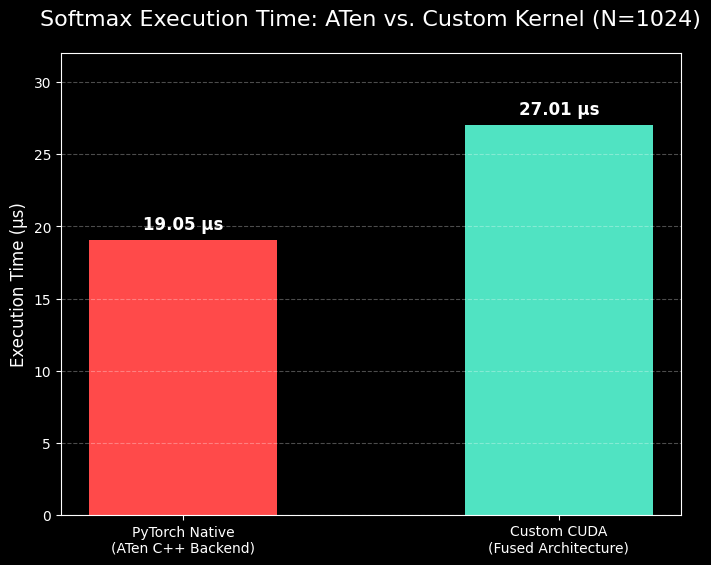

Graph saved as 'softmax_benchmark.png'


In [18]:
import matplotlib.pyplot as plt


implementations = ['PyTorch Native\n(ATen C++ Backend)', 'Custom CUDA\n(Fused Architecture)']
times_us = [pytorch_time_us, custom_time_us]

plt.figure(figsize=(8, 6))
plt.style.use('dark_background')

bars = plt.bar(implementations, times_us, color=['#ff4a4a', '#50e3c2'], width=0.5)

plt.title('Softmax Execution Time: ATen vs. Custom Kernel (N=1024)', fontsize=16, pad=20)
plt.ylabel('Execution Time (µs)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.ylim(0, max(times_us) + 5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f} µs',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.savefig('softmax_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as 'softmax_benchmark.png'")